# Corporate Credit Portfolio Simulation

Simulates a synthetic portfolio of **1 000 corporate credit exposures** with:
- Sector allocation weighted by observed SIC Division-II counts
- Credit ratings drawn from a **Normal(BB, σ)** distribution on the ordinal rating scale
- PD mapping derived directly from Fitch Ratings data (`ISIN_PD_DATA.csv`)
- EAD (Exposure at Default) simulated using **sector × rating-scaled Normal distributions**: IG names (AAA–BBB−) get larger exposures than speculative-grade, targeting an EAD-weighted average PD of ~1%

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

# ── Reproducibility ────────────────────────────────────────────────────────────
RANDOM_SEED = 1
N_EXPOSURES = 1_000
rng = np.random.default_rng(RANDOM_SEED)

## 1. Sector weights
Sectors and their relative frequencies are loaded from `sectors/sic_div2_counts.csv`.  
The number of exposures per sector is drawn proportionally to the observed PD-observation counts.

In [29]:
sectors_df = pd.read_csv(Path('../sectors/sic_div2_counts.csv'))
sectors_df = sectors_df[sectors_df['Sector'] != 'Unassigned'].copy()
sectors_df['weight'] = sectors_df['N_PD_observations'] / sectors_df['N_PD_observations'].sum()

print(sectors_df[['Sector', 'SIC Codes', 'N_PD_observations', 'weight']].to_string(index=False))

                              Sector SIC Codes  N_PD_observations   weight
    Finance, Insurance & Real Estate 6000-6999               4813 0.244588
                           Utilities 4900-4999               3234 0.164346
                 Light Manufacturing 2000-2999               2170 0.110275
                 Heavy Manufacturing 3000-3999               1995 0.101382
               Mining & Construction 1000-1999               1617 0.082173
                      Communications 4800-4899               1518 0.077142
                            Services 7000-7999               1364 0.069316
            Wholesale & Retail Trade 5000-5999               1296 0.065860
                      Transportation 4000-4799                924 0.046956
Health, Legal & Educational Services 8000-8999                449 0.022817
               Public Administration 9000-9999                298 0.015144


## 2. Rating scale and PD mapping

PDs are taken from the empirical averages observed in `data/PDs/ISIN_PD_DATA.csv` (Fitch Ratings).  
Ratings are ordered from best (position 0 = AAA) to worst (position 21 = D).

The distribution of ratings is **Normal** centred at **BB** (position 11 on the 0-indexed scale), with σ = 3.5, yielding a portfolio average PD of ~3%.

In [30]:
RATING_SCALE = [
    'AAA', 'AA+', 'AA',  'AA-',
    'A+',  'A',   'A-',
    'BBB+','BBB', 'BBB-',
    'BB+', 'BB',  'BB-',
    'B+',  'B',   'B-',
    'CCC+','CCC', 'CCC-',
    'CC',  'C',   'D'
]

# PDs sourced from Fitch data averages (ISIN_PD_DATA.csv)
PD_MAP = {
    'AAA':  0.0011,   'AA+':  0.000967, 'AA':   0.000833, 'AA-':  0.0007,
    'A+':   0.00065,  'A':    0.0006,   'A-':   0.0006,
    'BBB+': 0.0008,   'BBB':  0.0007,   'BBB-': 0.0020,
    'BB+':  0.0024,   'BB':   0.0050,   'BB-':  0.0103,
    'B+':   0.0137,   'B':    0.0193,   'B-':   0.0310,
    'CCC+': 0.2387,   'CCC':  0.2387,   'CCC-': 0.2387,
    'CC':   0.2387,   'C':    0.2387,   'D':    1.0000,
}

BB_POSITION = RATING_SCALE.index('BB')  # = 11
N_RATINGS   = len(RATING_SCALE)         # = 22

# σ = 3.5 → empirical avg PD ~3 % (within the 2–4 % target)
RATING_STD  = 3.5

print(f'BB position (0-indexed): {BB_POSITION}')
print(f'Rating std dev (σ):       {RATING_STD}')
print()
print('Rating → PD mapping:')
for r, p in PD_MAP.items():
    print(f'  {r:<6} {p:.4%}')

BB position (0-indexed): 11
Rating std dev (σ):       3.5

Rating → PD mapping:
  AAA    0.1100%
  AA+    0.0967%
  AA     0.0833%
  AA-    0.0700%
  A+     0.0650%
  A      0.0600%
  A-     0.0600%
  BBB+   0.0800%
  BBB    0.0700%
  BBB-   0.2000%
  BB+    0.2400%
  BB     0.5000%
  BB-    1.0300%
  B+     1.3700%
  B      1.9300%
  B-     3.1000%
  CCC+   23.8700%
  CCC    23.8700%
  CCC-   23.8700%
  CC     23.8700%
  C      23.8700%
  D      100.0000%


## 3. EAD parameters by sector

Each sector is assigned a **base mean EAD** (€M) and **std dev** reflecting its typical exposure size.  
Capital-intensive sectors (Utilities, Finance, Communications) carry larger average exposures;  
service-oriented sectors carry smaller ones.

The base mean is then scaled by a **rating-dependent multiplier** before drawing each exposure.  
IG names (AAA–BBB−) represent large, profitable corporations and receive a multiplier > 1;  
speculative-grade names receive a multiplier < 1. This induces a realistic **negative PD–EAD correlation**  
and targets an **EAD-weighted average PD of ~1%** (vs. a count-weighted average of ~3%).

EAD is drawn from `Normal(μ × mult, σ × mult)` per exposure and clipped at a minimum of €1M.

In [31]:
# Sector EAD parameters (€ millions): mean and std dev
# Reflect typical corporate loan / bond sizes per industry
EAD_PARAMS = {
    'Finance, Insurance & Real Estate':  {'mean': 50.0, 'std': 25.0},
    'Heavy Manufacturing':               {'mean': 35.0, 'std': 18.0},
    'Utilities':                         {'mean': 65.0, 'std': 30.0},
    'Light Manufacturing':               {'mean': 25.0, 'std': 12.0},
    'Communications':                    {'mean': 48.0, 'std': 22.0},
    'Mining & Construction':             {'mean': 40.0, 'std': 20.0},
    'Services':                          {'mean': 20.0, 'std': 10.0},
    'Wholesale & Retail Trade':          {'mean': 22.0, 'std': 11.0},
    'Transportation':                    {'mean': 38.0, 'std': 18.0},
    'Health, Legal & Educational Services': {'mean': 18.0, 'std':  9.0},
    'Public Administration':             {'mean': 30.0, 'std': 15.0},
}

# Rating-dependent EAD multiplier applied on top of the sector mean.
# IG names (AAA–BBB−) represent large, profitable corporations and carry
# significantly higher exposures; speculative-grade names are smaller.
# This negative PD–EAD correlation targets an EAD-weighted avg PD of ~1%.
RATING_EAD_MULTIPLIER = {
    'AAA':  4.0,  'AA+':  3.5,  'AA':   3.2,  'AA-':  2.8,
    'A+':   2.5,  'A':    2.2,  'A-':   2.0,
    'BBB+': 1.8,  'BBB':  1.6,  'BBB-': 1.4,
    'BB+':  1.2,  'BB':   1.0,  'BB-':  0.85,
    'B+':   0.75, 'B':    0.65, 'B-':   0.55,
    'CCC+': 0.40, 'CCC':  0.40, 'CCC-': 0.40,
    'CC':   0.40, 'C':    0.35, 'D':    0.30,
}

EAD_MIN_EUR_M = 1.0   # floor to avoid zero / negative EADs

ead_summary = pd.DataFrame(EAD_PARAMS).T.rename(columns={'mean': 'EAD mean (€M)', 'std': 'EAD std (€M)'})
ead_summary['CV'] = ead_summary['EAD std (€M)'] / ead_summary['EAD mean (€M)']
print('Base EAD params by sector (before rating multiplier):')
print(ead_summary.to_string())
print('\nRating EAD multipliers:')
print(pd.Series(RATING_EAD_MULTIPLIER).rename('multiplier').to_frame().T.to_string())

Base EAD params by sector (before rating multiplier):
                                      EAD mean (€M)  EAD std (€M)        CV
Finance, Insurance & Real Estate               50.0          25.0  0.500000
Heavy Manufacturing                            35.0          18.0  0.514286
Utilities                                      65.0          30.0  0.461538
Light Manufacturing                            25.0          12.0  0.480000
Communications                                 48.0          22.0  0.458333
Mining & Construction                          40.0          20.0  0.500000
Services                                       20.0          10.0  0.500000
Wholesale & Retail Trade                       22.0          11.0  0.500000
Transportation                                 38.0          18.0  0.473684
Health, Legal & Educational Services           18.0           9.0  0.500000
Public Administration                          30.0          15.0  0.500000

Rating EAD multipliers:
         

## 4. Simulate portfolio

In [37]:
# ── Sector assignment ──────────────────────────────────────────────────────────
sector_names   = sectors_df['Sector'].tolist()
sector_ranges  = sectors_df['SIC Codes'].tolist()
sector_weights = sectors_df['weight'].values

sector_idx = rng.choice(
    len(sector_names),
    size=N_EXPOSURES,
    p=sector_weights,
)

# ── Rating assignment (Normal centred at BB) ───────────────────────────────────
raw_positions    = rng.normal(loc=BB_POSITION, scale=RATING_STD, size=N_EXPOSURES)
rating_positions = np.clip(np.round(raw_positions).astype(int), 0, N_RATINGS - 1)
ratings          = [RATING_SCALE[i] for i in rating_positions]

# ── EAD simulation (sector × rating-scaled Normal, clipped at EAD_MIN_EUR_M) ──
# The sector base mean is multiplied by the rating multiplier so that IG names
# carry larger exposures, inducing the realistic negative PD–EAD correlation.
ead_values = np.empty(N_EXPOSURES)
for i, s_idx in enumerate(sector_idx):
    sector      = sector_names[s_idx]
    params      = EAD_PARAMS[sector]
    r_mult      = RATING_EAD_MULTIPLIER[ratings[i]]
    raw_ead     = rng.normal(loc=params['mean'] * r_mult, scale=params['std'] * r_mult)
    ead_values[i] = max(raw_ead, EAD_MIN_EUR_M)

# ── Build DataFrame ────────────────────────────────────────────────────────────
portfolio = pd.DataFrame({
    'exposure_id': range(1, N_EXPOSURES + 1),
    'sector':      [sector_names[i]  for i in sector_idx],
    'sic_range':   [sector_ranges[i] for i in sector_idx],
    'rating':      ratings,
    'pd':          [PD_MAP[r] for r in ratings],
    'ead_eur_m':   np.round(ead_values, 2),
})

portfolio['rating'] = pd.Categorical(
    portfolio['rating'],
    categories=RATING_SCALE,
    ordered=True,
)

print(f'Portfolio shape:       {portfolio.shape}')
print(f'Total EAD:             €{portfolio["ead_eur_m"].sum():,.1f}M')
print(f'Average EAD:           €{portfolio["ead_eur_m"].mean():.1f}M')
print(f'Average PD:            {portfolio["pd"].mean():.2%}')
print(f'EAD-weighted avg PD:   {(portfolio["pd"] * portfolio["ead_eur_m"]).sum() / portfolio["ead_eur_m"].sum():.2%}')
print()
portfolio.head(10)

Portfolio shape:       (1000, 6)
Total EAD:             €48,347.3M
Average EAD:           €48.3M
Average PD:            3.35%
EAD-weighted avg PD:   1.33%



,exposure_id,sector,sic_range,rating,pd,ead_eur_m
0,1,Transportation,4000-4799,B,0.0193,4.44
1,2,Wholesale & Retail Trade,5000-5999,CCC+,0.2387,13.09
2,3,"Finance, Insurance & Real Estate",6000-6999,BB,0.0050,24.90
3,4,Utilities,4900-4999,BBB,0.0007,73.82
4,5,Transportation,4000-4799,BB-,0.0103,28.69
5,6,Transportation,4000-4799,BB,0.0050,42.68
6,7,"Health, Legal & Educational Services",8000-8999,BB-,0.0103,9.98
7,8,Mining & Construction,1000-1999,BBB+,0.0008,47.81
8,9,Communications,4800-4899,CCC-,0.2387,5.33
9,10,Utilities,4900-4999,BB+,0.0024,110.36


## 5. Portfolio summary

In [33]:
print('=== Rating distribution ===')
rating_counts = (
    portfolio.groupby('rating', observed=True)
    .agg(count=('exposure_id', 'count'), total_ead=('ead_eur_m', 'sum'))
)
rating_counts['pct_count']  = rating_counts['count'] / N_EXPOSURES
rating_counts['pct_ead']    = rating_counts['total_ead'] / portfolio['ead_eur_m'].sum()
rating_counts['pd']         = rating_counts.index.map(PD_MAP)
print(rating_counts.to_string())

print('\n=== Sector summary ===')
sector_summary = (
    portfolio.groupby('sector')
    .agg(
        n_exposures  = ('exposure_id', 'count'),
        total_ead    = ('ead_eur_m',   'sum'),
        avg_ead      = ('ead_eur_m',   'mean'),
        std_ead      = ('ead_eur_m',   'std'),
        avg_pd       = ('pd',          'mean'),
    )
    .sort_values('total_ead', ascending=False)
)
sector_summary['ead_share'] = sector_summary['total_ead'] / sector_summary['total_ead'].sum()
sector_summary['avg_ead']   = sector_summary['avg_ead'].round(1)
sector_summary['std_ead']   = sector_summary['std_ead'].round(1)
print(sector_summary.to_string())

=== Rating distribution ===
        count  total_ead  pct_count   pct_ead        pd
rating                                                 
AA+         3     256.99      0.003  0.005278  0.000967
AA          8    1169.72      0.008  0.024024  0.000833
AA-         5     529.06      0.005  0.010866  0.000700
A+         16    1986.22      0.016  0.040793  0.000650
A          21    1831.39      0.021  0.037613  0.000600
A-         46    4735.92      0.046  0.097266  0.000600
BBB+       68    5485.02      0.068  0.112651  0.000800
BBB        70    4620.13      0.070  0.094888  0.000700
BBB-       92    5848.86      0.092  0.120123  0.002000
BB+       116    6085.56      0.116  0.124984  0.002400
BB        107    4175.98      0.107  0.085766  0.005000
BB-        95    3499.83      0.095  0.071879  0.010300
B+        101    2955.02      0.101  0.060690  0.013700
B          84    2519.08      0.084  0.051737  0.019300
B-         52    1188.77      0.052  0.024415  0.031000
CCC+       48     69

## 6. Visualisations

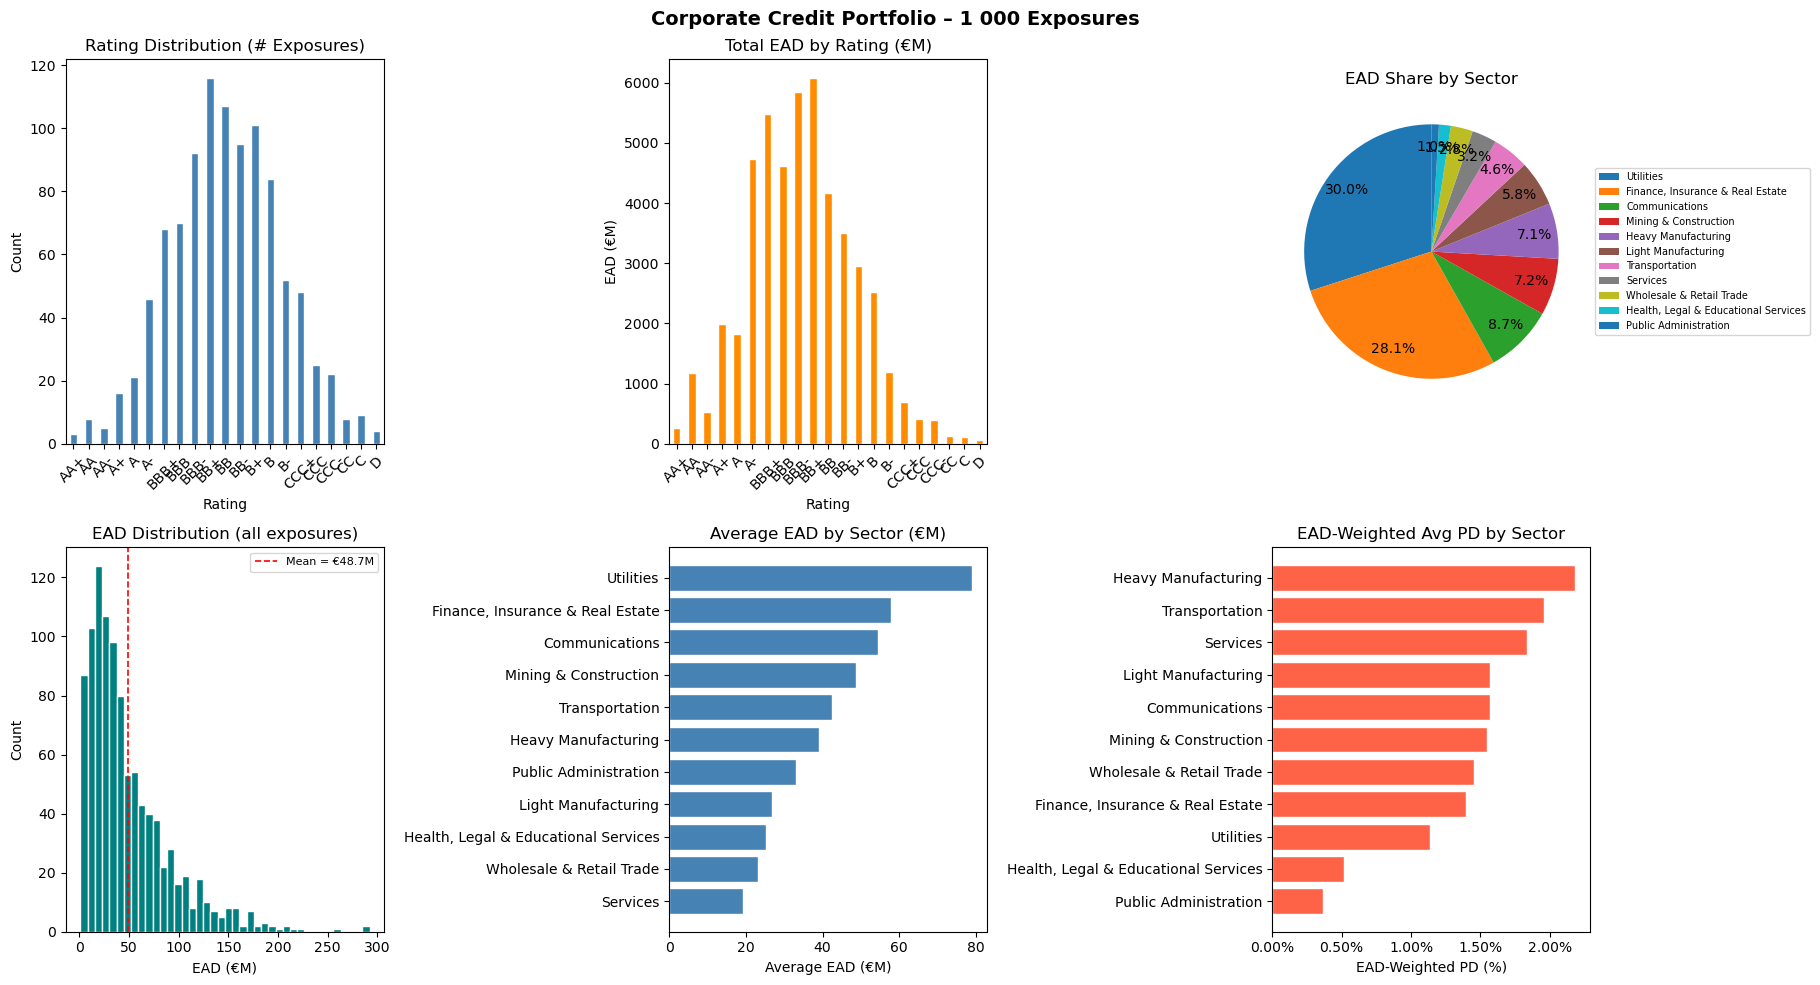

Charts saved to portfolio_simulation_charts.png


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Corporate Credit Portfolio – 1 000 Exposures', fontsize=14, fontweight='bold')

# ── 1. Rating frequency ────────────────────────────────────────────────────────
ax1 = axes[0, 0]
rating_counts['count'].plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Rating Distribution (# Exposures)')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# ── 2. EAD by rating ──────────────────────────────────────────────────────────
ax2 = axes[0, 1]
rating_counts['total_ead'].plot(kind='bar', ax=ax2, color='darkorange', edgecolor='white')
ax2.set_title('Total EAD by Rating (€M)')
ax2.set_xlabel('Rating')
ax2.set_ylabel('EAD (€M)')
ax2.tick_params(axis='x', rotation=45)

# ── 3. Sector EAD share ───────────────────────────────────────────────────────
ax3 = axes[0, 2]
ead_by_sector = portfolio.groupby('sector')['ead_eur_m'].sum().sort_values(ascending=False)
wedges, _, autotexts = ax3.pie(
    ead_by_sector.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
)
ax3.legend(
    wedges, ead_by_sector.index,
    loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=7,
)
ax3.set_title('EAD Share by Sector')

# ── 4. EAD distribution (histogram) ───────────────────────────────────────────
ax4 = axes[1, 0]
ax4.hist(portfolio['ead_eur_m'], bins=40, color='teal', edgecolor='white')
ax4.set_title('EAD Distribution (all exposures)')
ax4.set_xlabel('EAD (€M)')
ax4.set_ylabel('Count')
ax4.axvline(portfolio['ead_eur_m'].mean(), color='red', linestyle='--', linewidth=1.2,
            label=f'Mean = €{portfolio["ead_eur_m"].mean():.1f}M')
ax4.legend(fontsize=8)

# ── 5. Average EAD per sector (horizontal bars) ────────────────────────────────
ax5 = axes[1, 1]
avg_ead = portfolio.groupby('sector')['ead_eur_m'].mean().sort_values()
ax5.barh(avg_ead.index, avg_ead.values, color='steelblue', edgecolor='white')
ax5.set_title('Average EAD by Sector (€M)')
ax5.set_xlabel('Average EAD (€M)')

# ── 6. EAD-weighted PD by sector ──────────────────────────────────────────────
ax6 = axes[1, 2]
ead_wtd_pd = (
    portfolio.groupby('sector')
    .apply(lambda g: (g['pd'] * g['ead_eur_m']).sum() / g['ead_eur_m'].sum(), include_groups=False)
    .sort_values()
)
ax6.barh(ead_wtd_pd.index, ead_wtd_pd.values * 100, color='tomato', edgecolor='white')
ax6.set_title('EAD-Weighted Avg PD by Sector')
ax6.set_xlabel('EAD-Weighted PD (%)')
ax6.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))

plt.tight_layout()
plt.savefig('portfolio_simulation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Charts saved to portfolio_simulation_charts.png')

## 7. Export

In [35]:
out_path = Path('../data/portfolio_simulation.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
portfolio.to_csv(out_path, index=False)
print(f'Portfolio saved to {out_path}  ({len(portfolio)} rows)')
portfolio.dtypes

Portfolio saved to ../data/portfolio_simulation.csv  (1000 rows)


exposure_id       int64
sector           object
sic_range        object
rating         category
pd              float64
ead_eur_m       float64
dtype: object

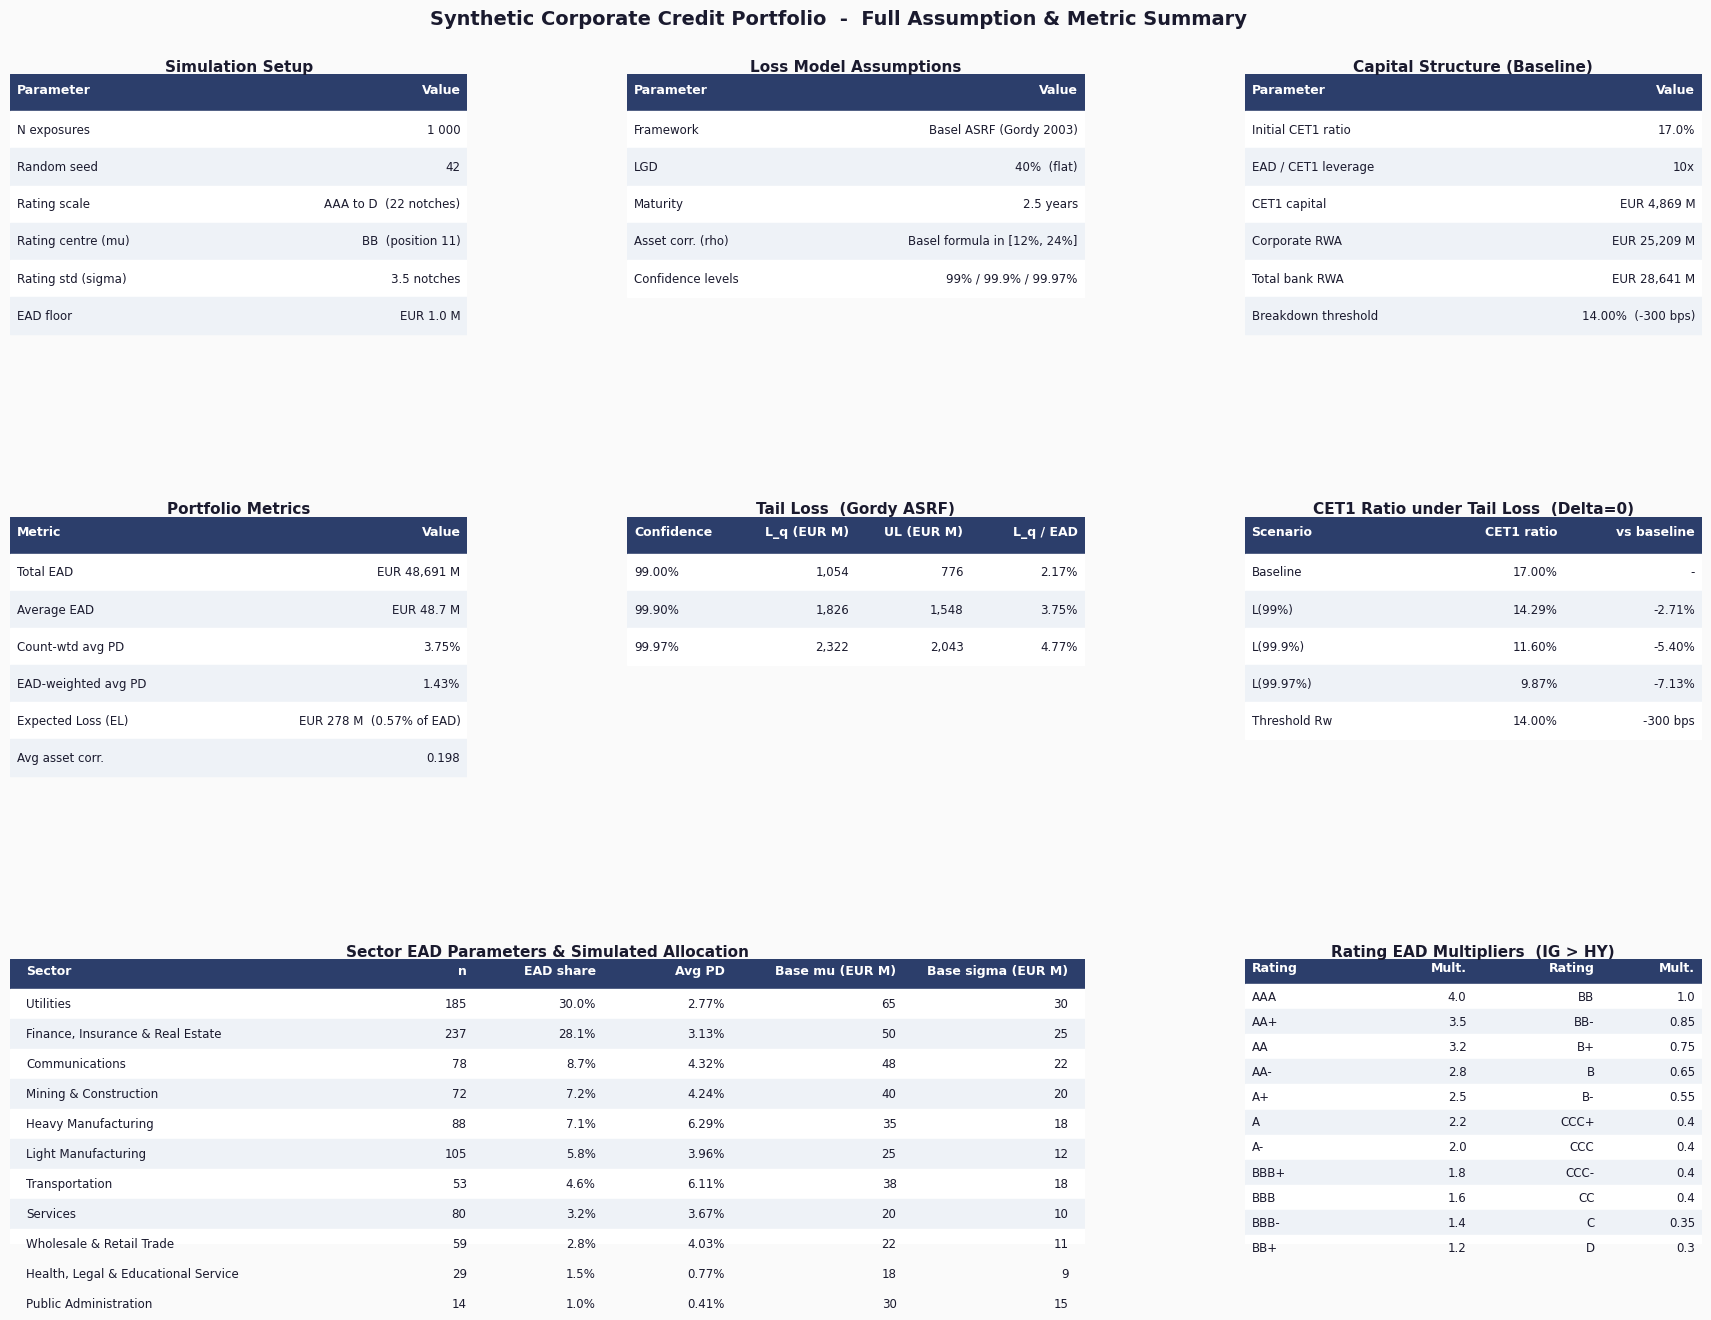

Saved to portfolio_summary_figure.png


In [36]:
# Summary figure: all assumptions & key metrics
from scipy.stats import norm
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from pd_pipeline.basel import asset_correlation_formula, calculate_capital_requirement

# Recompute downstream metrics inline
LGD            = 0.40
Q_999          = 0.999
MATURITY       = 2.5
CET1_RATIO_0   = 0.17
EAD_CET1_RATIO = 10.0
BREAKDOWN_BPS  = 300
THRESHOLD      = CET1_RATIO_0 - BREAKDOWN_BPS / 10_000

pd_arr  = portfolio['pd'].values
ead_arr = portfolio['ead_eur_m'].values
rho_arr = asset_correlation_formula(pd_arr)

# Gordy conditional losses
def gordy_loss(q):
    g_pd = norm.ppf(pd_arr)
    cond = norm.cdf((g_pd + np.sqrt(rho_arr) * norm.ppf(q)) / np.sqrt(1 - rho_arr))
    return float((ead_arr * LGD * cond).sum())

L_99   = gordy_loss(0.99)
L_999  = gordy_loss(0.999)
L_9997 = gordy_loss(0.9997)

# Basel IRB capital
K_base    = calculate_capital_requirement(pd_arr, LGD, rho_arr, maturity=MATURITY)
RWA_corp  = float(np.sum(ead_arr * K_base * 12.5))
EAD_total = float(ead_arr.sum())
CET1_cap  = EAD_total / EAD_CET1_RATIO
RWA_total = CET1_cap / CET1_RATIO_0
EL        = float((pd_arr * ead_arr * LGD).sum())

# Figure
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor('#fafafa')

title_kw  = dict(fontsize=11, fontweight='bold', color='#1a1a2e', va='top')
header_kw = dict(fontsize=9,  fontweight='bold', color='#ffffff')
cell_kw   = dict(fontsize=8.5, color='#1a1a2e', va='center')
head_col  = '#2c3e6b'

def draw_table(ax, rows, col_widths, row_height=0.13, header=True):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    for r_idx, row in enumerate(rows):
        y_top = 1.0 - r_idx * row_height
        y_cen = y_top - row_height / 2
        bg = head_col if (r_idx == 0 and header) else ('#eef2f7' if r_idx % 2 == 0 else 'white')
        ax.add_patch(plt.Rectangle((0, y_top - row_height), 1, row_height,
                                   color=bg, transform=ax.transAxes, zorder=0))
        x = 0
        for c_idx, (txt, cw) in enumerate(zip(row, col_widths)):
            kw = header_kw if (r_idx == 0 and header) else cell_kw
            align = 'left' if c_idx == 0 else 'right'
            pad = 0.015
            xpos = x + pad if align == 'left' else x + cw - pad
            ax.text(xpos, y_cen, str(txt), ha=align, transform=ax.transAxes, **kw)
            x += cw

gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      left=0.04, right=0.98, top=0.93, bottom=0.03)

fig.suptitle('Synthetic Corporate Credit Portfolio  -  Full Assumption & Metric Summary',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=0.98)

# 1. Simulation setup
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title('Simulation Setup', **title_kw)
draw_table(ax1, [
    ['Parameter',          'Value'],
    ['N exposures',        '1 000'],
    ['Random seed',        '42'],
    ['Rating scale',       'AAA to D  (22 notches)'],
    ['Rating centre (mu)', 'BB  (position 11)'],
    ['Rating std (sigma)', '3.5 notches'],
    ['EAD floor',          'EUR 1.0 M'],
], [0.62, 0.38])

# 2. Loss model
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('Loss Model Assumptions', **title_kw)
draw_table(ax2, [
    ['Parameter',             'Value'],
    ['Framework',             'Basel ASRF (Gordy 2003)'],
    ['LGD',                   '40%  (flat)'],
    ['Maturity',              '2.5 years'],
    ['Asset corr. (rho)',     'Basel formula in [12%, 24%]'],
    ['Confidence levels',     '99% / 99.9% / 99.97%'],
], [0.52, 0.48])

# 3. Capital structure
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_title('Capital Structure (Baseline)', **title_kw)
draw_table(ax3, [
    ['Parameter',           'Value'],
    ['Initial CET1 ratio',  f'{CET1_RATIO_0:.1%}'],
    ['EAD / CET1 leverage', f'{EAD_CET1_RATIO:.0f}x'],
    ['CET1 capital',        f'EUR {CET1_cap:,.0f} M'],
    ['Corporate RWA',       f'EUR {RWA_corp:,.0f} M'],
    ['Total bank RWA',      f'EUR {RWA_total:,.0f} M'],
    ['Breakdown threshold', f'{THRESHOLD:.2%}  (-{BREAKDOWN_BPS} bps)'],
], [0.60, 0.40])

# 4. Portfolio metrics
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_title('Portfolio Metrics', **title_kw)
ead_wtd_pd = (portfolio['pd'] * portfolio['ead_eur_m']).sum() / EAD_total
draw_table(ax4, [
    ['Metric',              'Value'],
    ['Total EAD',           f'EUR {EAD_total:,.0f} M'],
    ['Average EAD',         f'EUR {EAD_total/len(portfolio):,.1f} M'],
    ['Count-wtd avg PD',    f'{portfolio["pd"].mean():.2%}'],
    ['EAD-weighted avg PD', f'{ead_wtd_pd:.2%}'],
    ['Expected Loss (EL)',  f'EUR {EL:,.0f} M  ({EL/EAD_total:.2%} of EAD)'],
    ['Avg asset corr.',     f'{rho_arr.mean():.3f}'],
], [0.60, 0.40])

# 5. Tail loss
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_title('Tail Loss  (Gordy ASRF)', **title_kw)
draw_table(ax5, [
    ['Confidence', 'L_q (EUR M)', 'UL (EUR M)', 'L_q / EAD'],
    ['99.00%',  f'{L_99:,.0f}',   f'{L_99-EL:,.0f}',   f'{L_99/EAD_total:.2%}'],
    ['99.90%',  f'{L_999:,.0f}',  f'{L_999-EL:,.0f}',  f'{L_999/EAD_total:.2%}'],
    ['99.97%',  f'{L_9997:,.0f}', f'{L_9997-EL:,.0f}', f'{L_9997/EAD_total:.2%}'],
], [0.25, 0.25, 0.25, 0.25])

# 6. CET1 under stress
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_title('CET1 Ratio under Tail Loss  (Delta=0)', **title_kw)
def cet1_at(L):
    return (CET1_cap - L + EL) / RWA_total
draw_table(ax6, [
    ['Scenario',    'CET1 ratio',                   'vs baseline'],
    ['Baseline',    f'{CET1_RATIO_0:.2%}',          '-'],
    ['L(99%)',      f'{cet1_at(L_99):.2%}',         f'{cet1_at(L_99)-CET1_RATIO_0:+.2%}'],
    ['L(99.9%)',    f'{cet1_at(L_999):.2%}',        f'{cet1_at(L_999)-CET1_RATIO_0:+.2%}'],
    ['L(99.97%)',   f'{cet1_at(L_9997):.2%}',       f'{cet1_at(L_9997)-CET1_RATIO_0:+.2%}'],
    ['Threshold Rw', f'{THRESHOLD:.2%}',            f'-{BREAKDOWN_BPS} bps'],
], [0.38, 0.32, 0.30])

# 7. Sector allocation
ax7 = fig.add_subplot(gs[2, :2])
ax7.set_title('Sector EAD Parameters & Simulated Allocation', **title_kw)
ead_params_ref = {
    'Finance, Insurance & Real Estate': (50, 25),
    'Utilities': (65, 30),
    'Heavy Manufacturing': (35, 18),
    'Communications': (48, 22),
    'Mining & Construction': (40, 20),
    'Light Manufacturing': (25, 12),
    'Wholesale & Retail Trade': (22, 11),
    'Services': (20, 10),
    'Transportation': (38, 18),
    'Health, Legal & Educational Services': (18, 9),
    'Public Administration': (30, 15),
}
sector_s = (portfolio.groupby('sector', observed=False)
    .agg(n=('exposure_id','count'), ead=('ead_eur_m','sum'), avg_pd=('pd','mean'))
    .sort_values('ead', ascending=False))
sector_s['share'] = sector_s['ead'] / sector_s['ead'].sum()
rows7 = [['Sector', 'n', 'EAD share', 'Avg PD', 'Base mu (EUR M)', 'Base sigma (EUR M)']]
for sec, row in sector_s.iterrows():
    mu, sig = ead_params_ref.get(sec, ('-', '-'))
    rows7.append([sec[:35], str(int(row['n'])), f'{row["share"]:.1%}',
                  f'{row["avg_pd"]:.2%}', str(mu), str(sig)])
draw_table(ax7, rows7, [0.37, 0.07, 0.12, 0.12, 0.16, 0.16], row_height=0.105)

# 8. Rating multipliers
ax8 = fig.add_subplot(gs[2, 2])
ax8.set_title('Rating EAD Multipliers  (IG > HY)', **title_kw)
mult = {
    'AAA':4.0,'AA+':3.5,'AA':3.2,'AA-':2.8,'A+':2.5,'A':2.2,'A-':2.0,
    'BBB+':1.8,'BBB':1.6,'BBB-':1.4,'BB+':1.2,'BB':1.0,'BB-':0.85,
    'B+':0.75,'B':0.65,'B-':0.55,'CCC+':0.40,'CCC':0.40,'CCC-':0.40,
    'CC':0.40,'C':0.35,'D':0.30,
}
items = list(mult.items())
half  = (len(items) + 1) // 2
rows8 = [['Rating', 'Mult.', 'Rating', 'Mult.']]
for i in range(half):
    r1, m1 = items[i]
    r2, m2 = items[i + half] if i + half < len(items) else ('', '')
    rows8.append([r1, str(m1), str(r2), str(m2) if m2 != '' else ''])
draw_table(ax8, rows8, [0.28, 0.22, 0.28, 0.22], row_height=0.088)

plt.savefig('portfolio_summary_figure.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved to portfolio_summary_figure.png')
